## Project introduction :

This project aims to predict the probability that a borrower will experience
serious delinquency within the next two years.

## Problem description

The project follows this workflow:

1. Load the labeled training dataset.
2. Clean the data and handle missing values.
3. Split the data into training and validation sets.
4. Train the classification models.
5. Evaluate the models using ROC-AUC and classification metrics.
6. Save the selected trained model.
7. Load the unlabeled test dataset.
8. Generate probability predictions.
9. Create the final submission file.


# Imports and configuration

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.features import get_features, split_data
from src.train import build_model_a, build_model_b, train_model_a, train_model_b

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Data loading


In [48]:
train_path = "filtered_dg.csv"
df = pd.read_csv(train_path)

print(df.shape)
df.head()


(120269, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In this dataset of 120,269 rows and 11 columns, we focus on the target variable "SeriousDlqin2yrs", which indicates whether a customer experienced a serious delinquency within the next two years.
All remaining columns are used as features X, with particular emphasis on those that describe the customer’s financial health (such as income, debt ratio, and credit history–related variables).

### 1.1 Target distribution


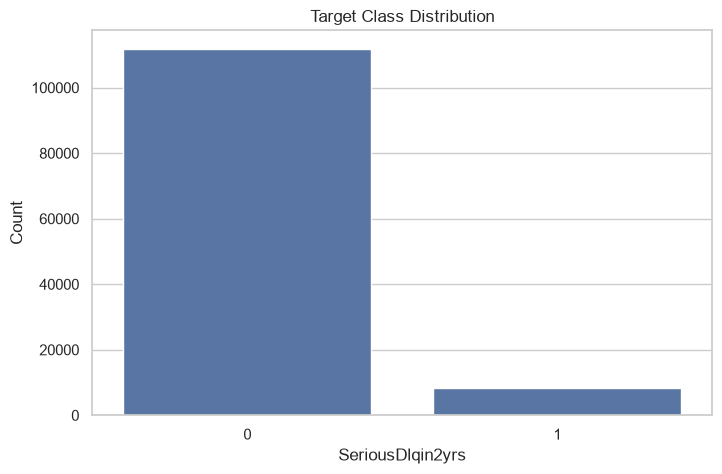

In [49]:
sns.countplot(data=df, x="SeriousDlqin2yrs")
plt.title("Target Class Distribution")
plt.xlabel("SeriousDlqin2yrs")
plt.ylabel("Count")
plt.show()


This plot highlights the class imbalance in the target variable: 'SeriousDlqin2yrs' is predominantly 0, meaning relatively few customers are observed with a serious delinquency within two years. Such imbalance can make it difficult for the model to learn the minority class, so we use 'class_weight="balanced"' in the logistic regression to better detect customers who are likely to experience repayment difficulties.

### 1.2 Missing values


In [50]:
raw_df = pd.read_csv("GiveMeSomeCredit/cs-training.csv")

missing_raw = raw_df.isna().sum()
missing_raw = missing_raw[missing_raw > 0].sort_values(ascending=False)



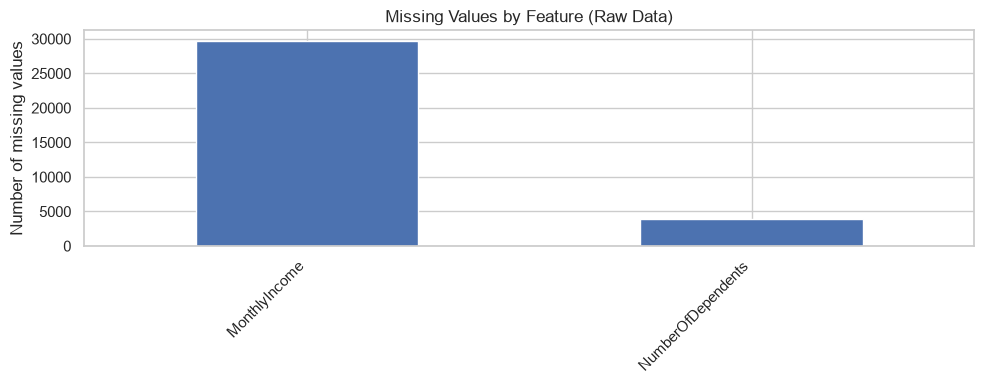

In [51]:
plt.figure(figsize=(10, 4))
missing_raw.plot(kind="bar")
plt.title("Missing Values by Feature (Raw Data)")
plt.ylabel("Number of missing values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In the raw training data, only two features contain missing values: 'MonthlyIncome' and 'NumberOfDependents'.
MonthlyIncome has 29,731 missing entries, which is a substantial portion of the dataset and suggests that income information is not always available or properly recorded.
'NumberOfDependents' has 3,924 missing values, indicating that the number of dependents is also sometimes unknown.
These missing values need to be handled during preprocessing (for example, via imputation or filtering) to avoid biased estimates and to ensure that the model can be trained on a clean, consistent feature set.

### 1.3 Descriptive statistics


In [52]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,120269.000000,120269.000000,120269.000000,120269.000000,120269.000000,1.202690e+05,120269.000000,120269.000000,120269.000000,120269.000000,120269.000000
mean,0.069486,5.899873,51.289792,0.381769,26.598777,6.670221e+03,8.758475,0.211925,1.054519,0.187829,0.851832
std,0.254280,257.040685,14.426684,3.499234,424.446457,1.438467e+04,5.172835,3.465276,1.149273,3.447901,1.148391
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.035084,40.000000,0.000000,0.143388,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.177282,51.000000,0.000000,0.296023,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.579428,61.000000,0.000000,0.482559,8.249000e+03,11.000000,0.000000,2.000000,0.000000,2.000000
max,1.000000,50708.000000,103.000000,98.000000,61106.500000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


### 1.4 Correlation matrix


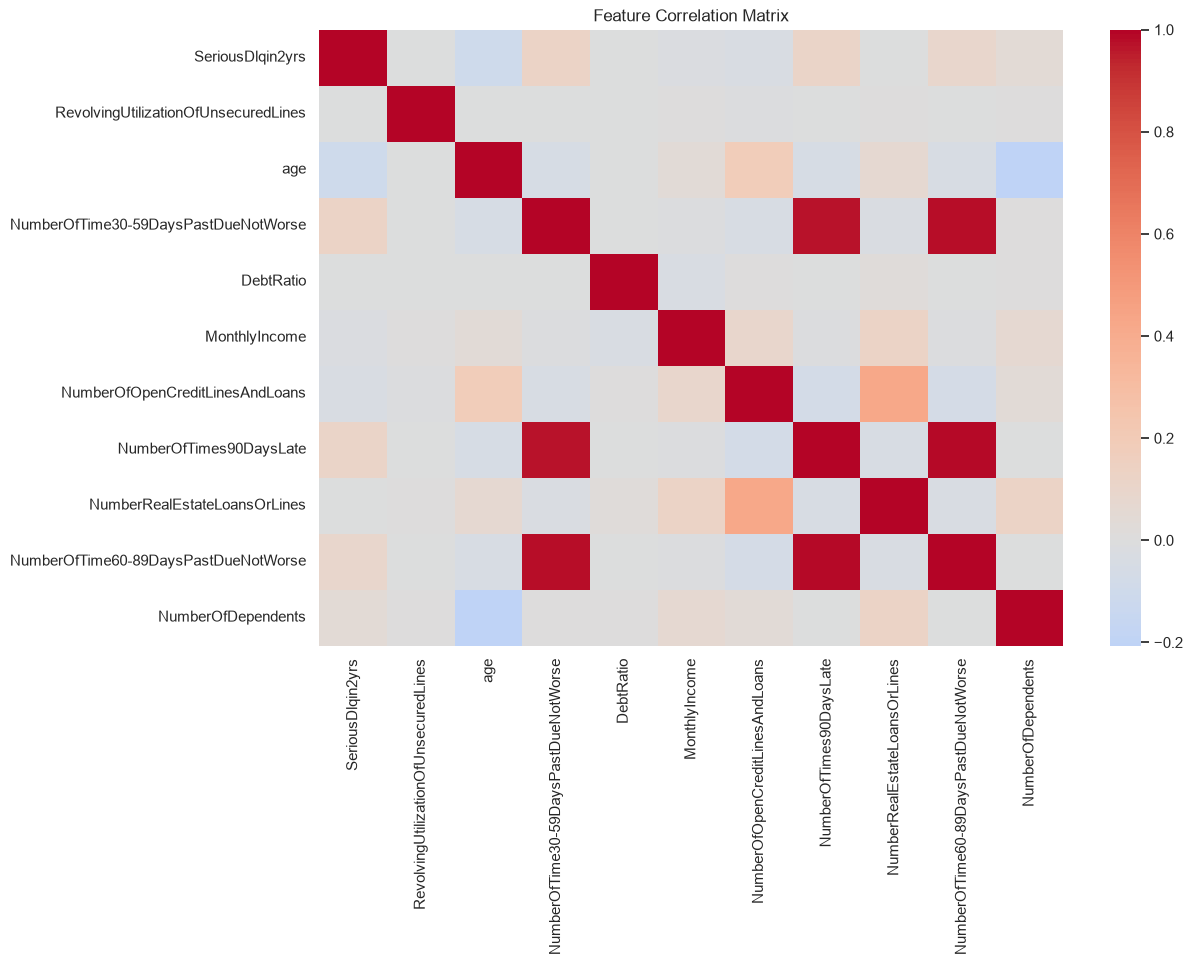

In [53]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()


The correlation matrix highlights a few important patterns in the data.
First, customers who are 30–59 days past due ('NumberOfTime30-59DaysPastDueNotWorse') tend to also be 90 days or more past due ('NumberOfTimes90DaysLate'), which is consistent with the idea that repayment issues often repeat and escalate over time.
Second, there is a noticeable positive correlation between the number of open credit lines and loans ('NumberOfOpenCreditLinesAndLoans') and the number of real estate loans or lines ('NumberRealEstateLoansOrLines': borrowers who have several credit lines typically also hold one or more real estate–related loans.
These relationships confirm that the delinquency and credit-line variables capture related aspects of a customer’s credit behavior and exposure.

## 2. Feature preparation and split


In [54]:
from src.features import get_features, split_data

X, y = get_features(df, target_col="SeriousDlqin2yrs")
X_train, X_val, y_train, y_val = split_data(X, y)

X_train.shape, X_val.shape


((96215, 10), (24054, 10))

Here the function 'get_features' will separate X and the target y. We're also using 'split_data' with 80/20 proportions and "random_state = 42", splitting the data will help evaluating generalization and avoid overlearning on the train.

## 3. Model training


### 3.1 model A

In [55]:
from src.train import build_model_a, train_model_a

model_a = train_model_a(X_train, y_train)


Model A is a simple baseline logistic regression classifier.
It uses the raw numerical features as inputs and fits a 'LogisticRegression' model without any explicit handling of class imbalance. The goal of Model A is to serve as a baseline: it shows how a standard logistic regression performs on this dataset before adding any additional improvements such as feature scaling or class balancing.

### 3.2 model B (final)

In [56]:
from src.train import build_model_b, train_model_b

model_b = train_model_b(X_train, y_train)


Model B is an improved version of the logistic regression classifier that explicitly addresses two key issues of the dataset: feature scaling and strong class imbalance. Standardizing the features helps the logistic regression optimizer converge more reliably and prevents features with large numeric scales from dominating the model.
Using 'class_weight="balanced"' compensates for the strong class imbalance by automatically adjusting the loss function so that misclassifying a delinquent customer (class 1) is penalized more than misclassifying a non-delinquent one (class 0).
		In practice, Model B achieves a significantly higher validation AUC than Model A, which is why it is selected as the final model for generating the Kaggle submission.

## 4. Model evaluation on validation set

#### AUC, classification report, confusion matrix

In [57]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

proba_val_b = model_b.predict_proba(X_val)[:, 1]
pred_val_b = model_b.predict(X_val)

auc_val_b = roc_auc_score(y_val, proba_val_b)
print("Validation AUC (Model B):", auc_val_b)

print("\nClassification report (Model B):")
print(classification_report(y_val, pred_val_b))

print("\nConfusion matrix (Model B):")
print(confusion_matrix(y_val, pred_val_b))

cm = confusion_matrix(y_val, pred_val_b)
tn, fp, fn, tp = cm.ravel()
print("True Positives:", tp)
print("False Negatives:", fn)

Validation AUC (Model B): 0.8002384479356537

Classification report (Model B):
              precision    recall  f1-score   support

           0       0.97      0.84      0.90     22356
           1       0.23      0.62      0.33      1698

    accuracy                           0.82     24054
   macro avg       0.60      0.73      0.61     24054
weighted avg       0.91      0.82      0.86     24054


Confusion matrix (Model B):
[[18751  3605]
 [  651  1047]]
True Positives: 1047
False Negatives: 651


In the confusion matrix,
- the true positives correspond to customers who actually experienced a serious delinquency and were correctly classified as high risk by the model. It means a customer who will actually default is classified as low risk. The bank may grant or maintain credit to this customer and face a potential loss when the customer fails to repay.
- The false negatives are customers who did default but were incorrectly predicted as low risk, meaning the bank would not anticipate their repayment issues. It means a customer who would not default is classified as high risk. In this case, the bank might refuse credit or tighten conditions unnecessarily, which hurts revenue and customer satisfaction but usually does not generate a direct financial loss as severe as a default.

For this reason, the model should prioritize reducing false negatives, even if that implies accepting more false positives.

### 4.1 ROC curve

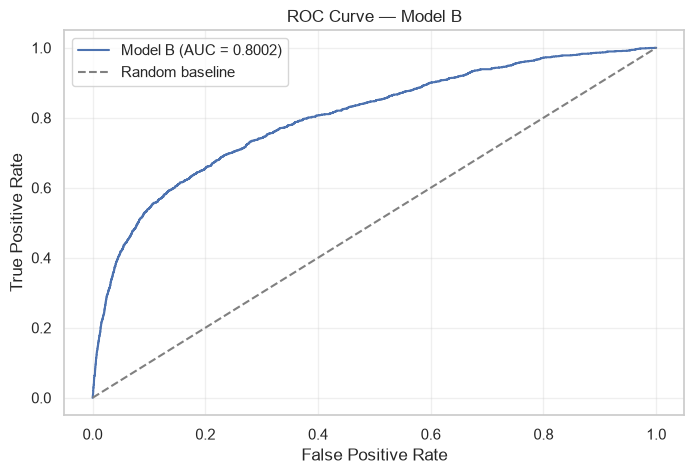

In [58]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, proba_val_b)

plt.plot(fpr, tpr, label=f"Model B (AUC = {auc_val_b:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random baseline")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model B")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In practice, this trade-off can be controlled by adjusting the decision threshold on the predicted probabilities: lowering the threshold will typically reduce false negatives (catch more risky customers) at the expense of increasing false positives.

### 4.2 Confusion matrix

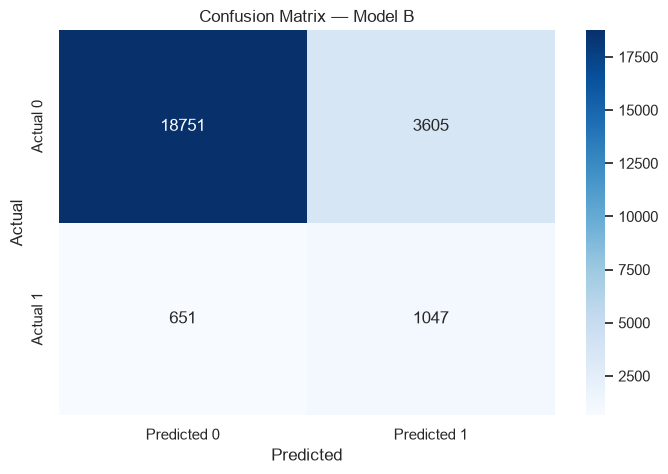

In [59]:
cm = confusion_matrix(y_val, pred_val_b)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)
plt.title("Confusion Matrix — Model B")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The confusion matrix shows that Model B correctly classifies most non-delinquent customers (18,751 true negatives) but also produces 3,605 false positives. For the delinquent class, it correctly identifies 1,047 high-risk customers (true positives) while missing 651 delinquent customers (false negatives). From a business perspective, these false negatives are the most critical errors, because they correspond to customers who will default but are predicted as low risk.

## 5. Overfitting check

In [60]:
proba_train_b = model_b.predict_proba(X_train)[:, 1]
auc_train_b = roc_auc_score(y_train, proba_train_b)

print("AUC train      :", auc_train_b)
print("AUC validation :", auc_val_b)
print("Gap            :", auc_train_b - auc_val_b)


AUC train      : 0.7956396413895543
AUC validation : 0.8002384479356537
Gap            : -0.004598806546099343


The overfitting check shows very similar performance on the training and validation sets (train AUC = 0.796, validation AUC = 0.800, gap ≈ 0.005). This small gap indicates that the model does not exhibit clear signs of overfitting and generalizes well to unseen data.

## 6. Final model and test prediction


In [61]:
import joblib

# Save model
joblib.dump(model_b, "model_b.joblib")

# Load test data and generate prediction (simplified example)
test_path = "filtered_di.csv"
df_test = pd.read_csv(test_path)
df_test = df_test.drop(columns=["Unnamed: 0"], errors="ignore")

from src.features import get_preds_features
X_test_final = get_preds_features(df_test)

model_b_loaded = joblib.load("model_b.joblib")
probs_test = model_b_loaded.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    "Id": range(1, len(probs_test) + 1),
    "Probability": probs_test
})

submission.head()


,Id,Probability
0,1,0.369217
1,2,0.381649
2,3,0.332509
3,4,0.599554
4,5,0.500490


The submission dataframe contains the final predictions that are sent to Kaggle.
Each row corresponds to one customer from the test set, identified by the 'Id' column.
The 'Probability' column stores the model’s estimated probability that this customer will experience a serious delinquency within the next two years ('SeriousDlqin2yrs' = 1).
This dataframe is exported to "submission.csv" and uploaded to Kaggle, where the competition platform computes the final ROC-AUC score on the hidden test labels.

## 7. Conclusion


In this project, we built a logistic regression model to predict serious credit delinquency
within two years.
The final model achieved a validation AUC of 0.8002, a public Kaggle score of 0.80242 and a private score of 0.80970.
The small train-validation gap indicates no clear overfitting. Logistic Regression with class balancing and standardization turned out to be a strong baseline for this tabular credit scoring problem.
Future work could explore more complex models (e.g. Gradient Boosting, XGBoost, LightGBM) and more advanced feature engineering.

In [ ]:
@misc{GiveMeSomeCredit,
    author = {Credit Fusion and Will Cukierski},
    title = {Give Me Some Credit},
    year = {2011},
    howpublished = {\url{https://kaggle.com/competitions/GiveMeSomeCredit}},
    note = {Kaggle}
}